In [51]:
import pandas as pd
import seaborn as sns
from sklearn import model_selection
import matplotlib.pyplot as plt
import eli5
from eli5.sklearn import PermutationImportance
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore') 

In [ ]:
TRAIN_DATA = "../data/model_ready/train.csv"

In [ ]:
train_df = pd.read_csv(TRAIN_DATA)

In [34]:
train_df.columns

Index(['Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'UMCSENT', 'RSXFS', 'PCE', 'has_MarkDown1',
       'has_MarkDown2', 'has_MarkDown3', 'has_MarkDown4', 'has_MarkDown5',
       'is_return', 'Year', 'Month', 'Week', 'Quarter', 'DayOfYear',
       'WeekOfMonth', 'IsMonthStart', 'IsMonthEnd', 'IsYearStart', 'IsYearEnd',
       'DaysInMonth', 'YearProgress', 'HolidayType', 'IsPreHoliday',
       'IsPostHoliday', 'HolidayProximity', 'IsPeakSeason', 'IsBackToSchool',
       'TotalMarkDown', 'ActiveMarkDownCount', 'AvgMarkDownAmount',
       'MaxMarkDown', 'HasAnyMarkDown', 'TypeEncoded', 'SizePerType',
       'StoreDeptCount', 'DeptFrequency', 'SizeQuartile', 'EconIndex',
       'ConsumerConfRatio', 'RealSpendingPerCapita', 'EconMomentum',
       'FuelBurden', 'PurchasingPower', 'Lag_Sales_1w', 'Lag_Sales_2w',
       'Lag_Sales_4w', 'Rolling_Mean_4w', 'Rolling_Mean_8w'

In [35]:
TARGETS = [
    'Year', 'Month', 'Week', 'Quarter', 'DayOfYear',
    'WeekOfMonth', 'IsMonthStart', 'IsMonthEnd', 'IsYearStart', 'IsYearEnd',
    'DaysInMonth', 'YearProgress', "Sales_Class"
    ]


In [36]:
features = [feature for feature in train_df.columns if feature not in TARGETS]

In [37]:
X = train_df[features].copy()
y = train_df.Sales_Class.copy()

In [38]:
data_sample = train_df.copy().sample(frac=.25)
X_sample = data_sample[features].copy()
y_sample = data_sample.Sales_Class.copy()

In [39]:
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(X_sample, y_sample, random_state=0, test_size=0.15)

In [40]:
feat_model = xgb.XGBRegressor(random_state=0).fit(X_train, y_train)

In [41]:
perm = PermutationImportance(feat_model, random_state=1).fit(X_valid, y_valid)
features = eli5.show_weights(perm, top=len(X_train.columns), feature_names = X_valid.columns.tolist())

In [49]:
features_weights = eli5.show_weights(perm, top=len(X_train.columns), feature_names = X_valid.columns.tolist())
features_weights

Weight,Feature
1.0387 ± 0.0215,Lag_Sales_1w
0.2393 ± 0.0099,Size
0.2042 ± 0.0076,Lag_Sales_4w
0.1057 ± 0.0023,Rolling_Mean_4w
0.0875 ± 0.0067,Rolling_Mean_8w
0.0761 ± 0.0026,Lag_Sales_2w
0.0528 ± 0.0024,Store
0.0401 ± 0.0016,Rolling_Mean_12w
0.0275 ± 0.0015,StoreDeptCount
0.0195 ± 0.0008,SizePerType


In [61]:
f_importances = pd.Series(dict(zip(X_valid.columns.tolist(), perm.feature_importances_))).sort_values(ascending=False)
weights = eli5.show_weights(perm, top=len(X_train.columns), feature_names=X_valid.columns.tolist())
result = pd.read_html(weights.data)[0]
result.head(40)

,Weight,Feature
0,1.0387 ± 0.0215,Lag_Sales_1w
1,0.2393 ± 0.0099,Size
2,0.2042 ± 0.0076,Lag_Sales_4w
3,0.1057 ± 0.0023,Rolling_Mean_4w
4,0.0875 ± 0.0067,Rolling_Mean_8w
5,0.0761 ± 0.0026,Lag_Sales_2w
6,0.0528 ± 0.0024,Store
7,0.0401 ± 0.0016,Rolling_Mean_12w
8,0.0275 ± 0.0015,StoreDeptCount
9,0.0195 ± 0.0008,SizePerType


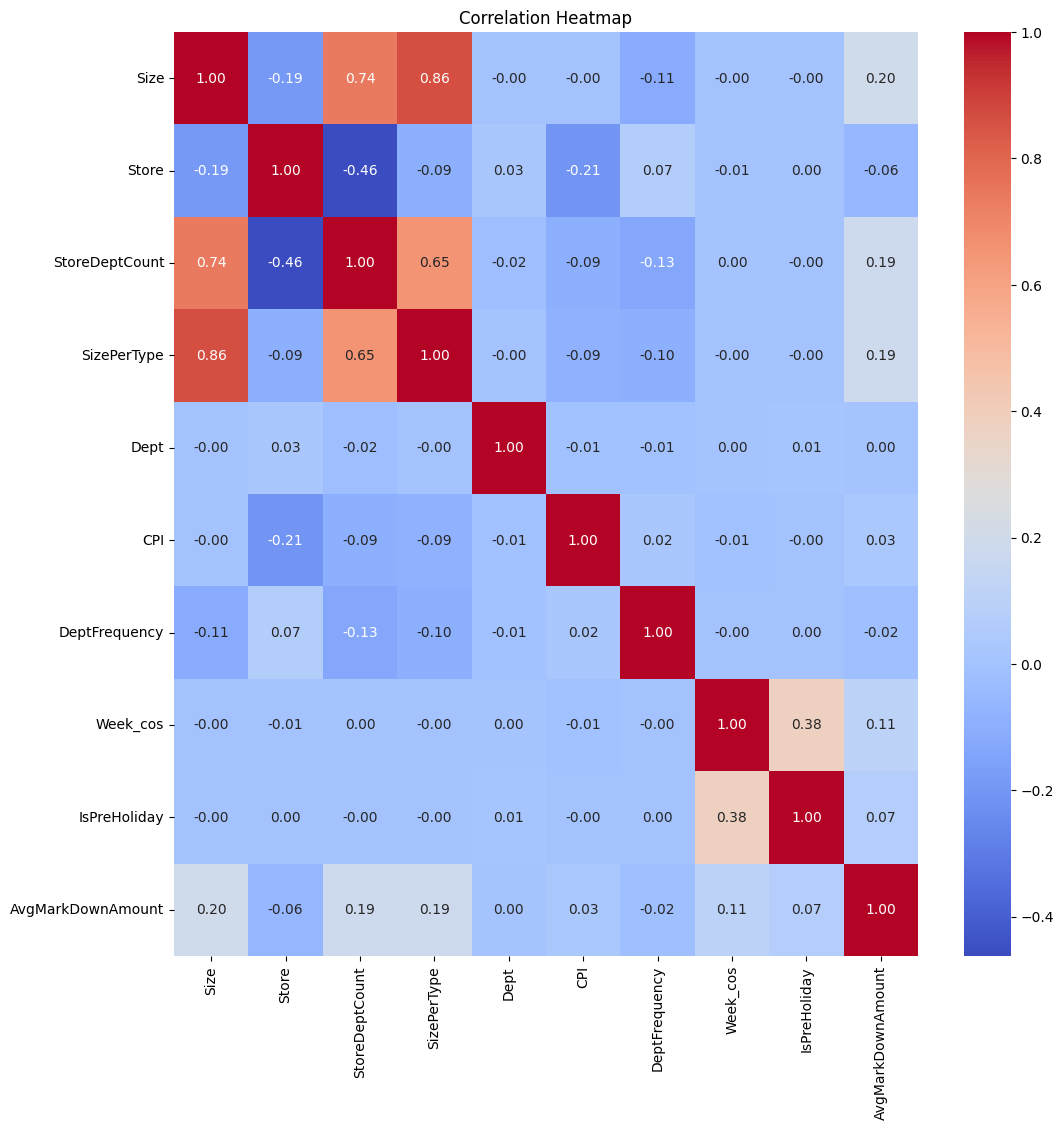

In [55]:
# NOTE: for the person reading this ... 
# we manually looked at multiple correlation matrices and decidend on which features to keep, and which features to discard

features_subset = [
    "Size",
    "Store",
    "StoreDeptCount",
    "SizePerType",
    "Dept",
    "CPI",
    "DeptFrequency",
    "Week_cos",
    "IsPreHoliday",
    # "Temperature",
    # "Unemployment",
    # "PurchasingPower",
    # "Week_sin",
    # # "MarkDown5",
    # "Fuel_Price",
    # # "FuelBurden",
    # "ConsumerConfRatio",
    # # "MarkDown2",
    "AvgMarkDownAmount",
    # # "Temp_Season",
    # # "MarkDown4",
    # # "Month_sin",
    # # "MaxMarkDown",
    # # "MarkDown3",
    # # "HolidayType",
    # # "EconMomentum",
    # # "TotalMarkDown",
    # # "MarkDown1",
    # # "HolidayProximity",
    # # "Econ_Size",
    # # "Holiday_Size",
    # # "RSXFS"
    ]


matrix = X_train.loc[:, features_subset].corr()
plt.figure(figsize=(12, 12))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [57]:
# we finally settled on these features
features_selected = [
    "Size",
    "Size",
    "Store",
    "Dept",
    "CPI",
    "DeptFrequency",
    "Week_cos",
    "IsPreHoliday",
    "Week_sin",
    "Fuel_Price",
    "ConsumerConfRatio",
    "AvgMarkDownAmount"
    ]

features_selected

['Size',
 'Size',
 'Store',
 'Dept',
 'CPI',
 'DeptFrequency',
 'Week_cos',
 'IsPreHoliday',
 'Week_sin',
 'Fuel_Price',
 'ConsumerConfRatio',
 'AvgMarkDownAmount']